In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/MPS_Antisocial_Behaviour--1-.csv", low_memory=False)

# Check for missing values
print("Missing values in each column before preprocessing:")
print(df.isnull().sum())

# Handle missing values: Impute or drop columns with high amounts of missing data
# Drop columns with excessive missing data (adjust based on your needs)
columns_to_drop = ['Opening_Type_2', 'Opening_Type_3', 'Close_Type_2', 'Close_Type_3', 'Resolution_Type_2', 'Ward_Code', 'Safer_Neighborhood_Team_Name', 'Safer_Neighborhood_Team_Code', 'Safer_Neighborhood_Team_Borough_Name', 'Safer_Neighborhood_Team_Borough_Code']
df = df.drop(columns=columns_to_drop)

# Impute missing values in 'Opening_Type_1', 'Close_Type_1', 'Resolution_Type_1', etc.
df['Opening_Type_1'].fillna(df['Opening_Type_1'].mode()[0], inplace=True)
df['Close_Type_1'].fillna(df['Close_Type_1'].mode()[0], inplace=True)
df['Resolution_Type_1'].fillna(df['Resolution_Type_1'].mode()[0], inplace=True)

# Drop rows with missing critical data that cannot be imputed (if needed)
df = df.dropna(subset=['Date', 'Hour', 'OP01', 'Response_Time', 'Duplicate', 'ASBCount'])

# Convert 'Date' and 'Hour' to proper datetime format
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Hour'])

# Convert categorical columns to categories
df['Opening_Type_1'] = df['Opening_Type_1'].astype('category')
df['Close_Type_1'] = df['Close_Type_1'].astype('category')
df['Resolution_Type_1'] = df['Resolution_Type_1'].astype('category')

# Extract the hour from the datetime
df['Hour'] = df['Datetime'].dt.hour

# Print the preprocessed DataFrame
print("\nPreprocessed DataFrame:")
print(df.head())  # Prints the first few rows of the DataFrame to check the results

# Optionally, check the shape after preprocessing to see how many rows and columns remain
print("\nDataFrame shape after preprocessing:", df.shape)


Missing values in each column before preprocessing:
Date                                         0
Hour                                         0
OP01                                         0
Opening_Type_1                               0
OP02                                       416
Opening_Type_2                            3894
OP03                                     11582
Opening_Type_3                          142757
CL01                                      2647
Close_Type_1                              3066
CL02                                     20422
Close_Type_2                            253450
CL03                                     20556
Close_Type_3                            255405
Resolution_Type_1                         2715
Resolution_Type_2                       235160
Ward                                     20350
Ward_Code                               255432
Response_Time                                0
Duplicate                                    0
ASBCount

<ipython-input-2-c0454941672f>:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Opening_Type_1'].fillna(df['Opening_Type_1'].mode()[0], inplace=True)
<ipython-input-2-c0454941672f>:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,


Preprocessed DataFrame:
         Date  Hour  OP01 Opening_Type_1 OP02 OP03 CL01  Close_Type_1 CL02  \
0  2024-04-07    19   215   ASB Nuisance  202       215  ASB Nuisance        
1  2024-04-01    20   215   ASB Nuisance  601       215  ASB Nuisance        
2  2024-04-14    16   215   ASB Nuisance  202  601  215  ASB Nuisance        
3  2024-04-04    18   215   ASB Nuisance  202       215  ASB Nuisance        
4  2024-04-02    18   215   ASB Nuisance  204  211  215  ASB Nuisance        

  CL03               Resolution_Type_1  Ward  Response_Time Duplicate  \
0       Police Attendance Not Required  WA11              0        No   
1                    Inform / Informed  AS45              0        No   
2                              Linked   AW20              0        No   
3                    Inform / Informed  CE12           1431        No   
4                    Inform / Informed  WA63              0        No   

   ASBCount            Datetime Ward_WardCode  
0         1 2024-04

Opening_Type_1
ASB Nuisance         219497
ASB Personal          25523
ASB Environmental     10384
Substance misuse         28
Name: count, dtype: int64

Most Frequent Types of Antisocial Behaviour:
Opening_Type_1: ASB Nuisance
Opening_Type_2: Rowdy Or Inconsiderate Behaviour
Opening_Type_3: Drug Related
Close_Type_1: ASB Nuisance
Close_Type_2: ASB Nuisance
Close_Type_3: Unlisted Crime
Resolution_Type_1: Inform / Informed
Resolution_Type_2: No Offences Disclosed

Most Frequent Time for Antisocial Behaviour: 19:00 hour


<ipython-input-3-2502a4c17fb9>:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Hour', data=df, palette='viridis')


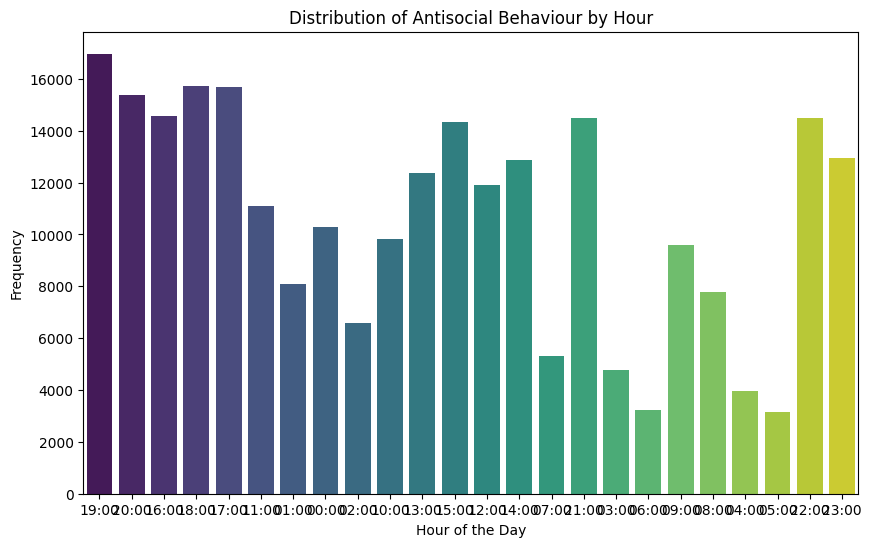


Boroughs/Areas with Most Antisocial Behaviour:
Safer_Neighborhood_Team_Borough_Name
Westminster                 14611
Tower Hamlets               12470
Ealing                      11359
Camden                      11084
Newham                      11012
Brent                       10716
Lambeth                     10481
Southwark                   10315
Islington                    9525
Hackney                      9518
Croydon                      9346
Haringey                     9251
Barnet                       9186
Enfield                      9028
Waltham Forest               8983
Wandsworth                   8097
Hounslow                     8044
Lewisham                     7480
Greenwich                    6811
Hillingdon                   6810
Hammersmith and Fulham       6530
Redbridge                    6237
Bromley                      5874
Harrow                       5484
Havering                     5475
Kensington and Chelsea       5030
Barking and Dagenham         48

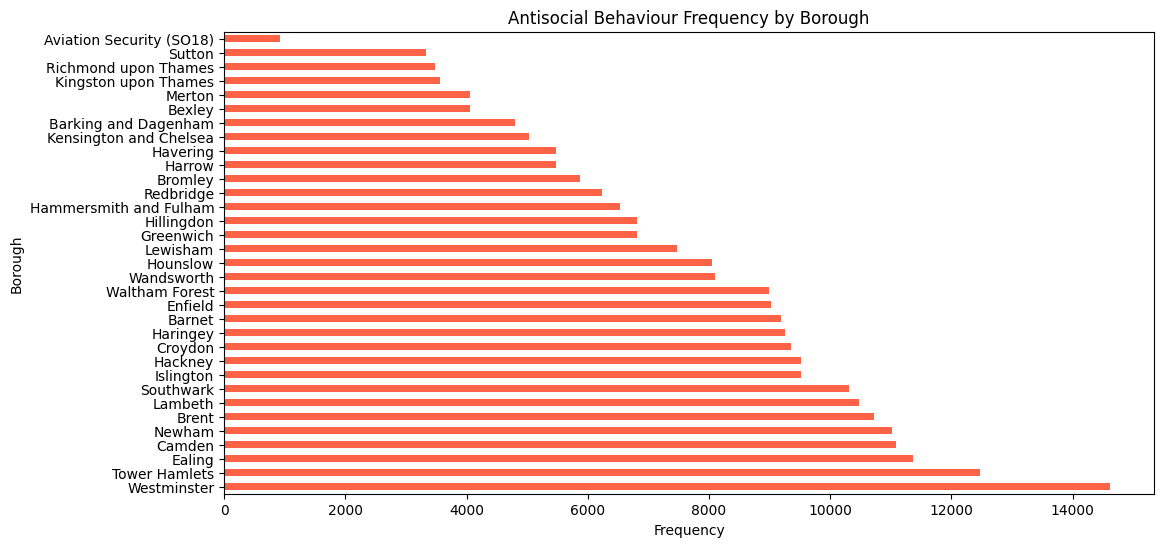

<ipython-input-3-2502a4c17fb9>:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Hour', data=df, palette='Blues')


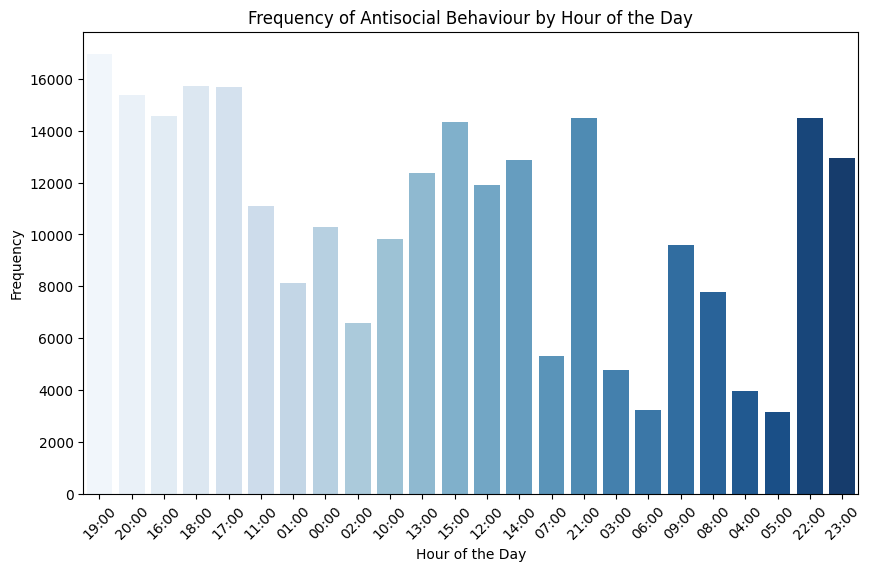

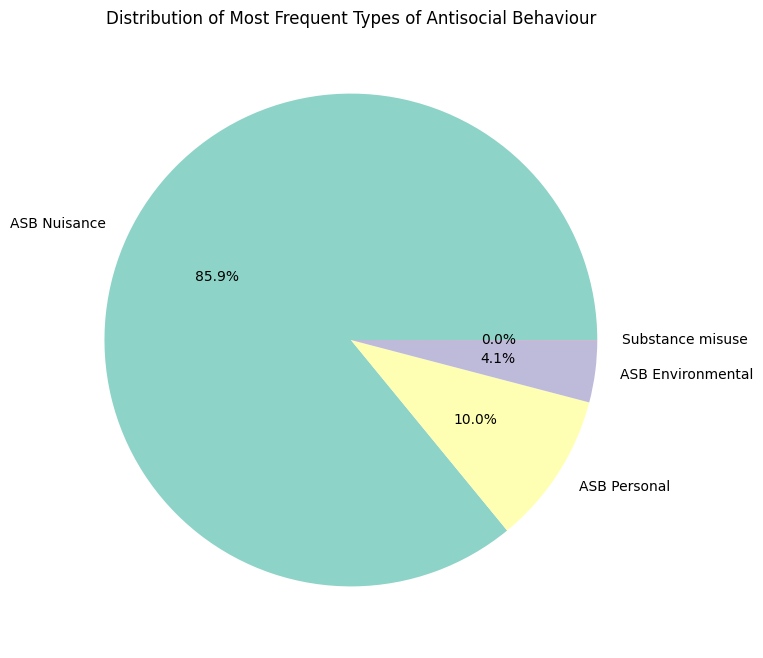


Descriptive Statistics for Numeric Columns:
                OP01  Response_Time  ASBCount
count  255432.000000   2.554320e+05  255432.0
mean      214.918370   6.512667e+03       1.0
std         2.166979   4.909032e+04       0.0
min        11.000000   0.000000e+00       1.0
25%       215.000000   0.000000e+00       1.0
50%       215.000000   0.000000e+00       1.0
75%       215.000000   5.980000e+02       1.0
max       216.000000   1.521844e+06       1.0


In [3]:
# Identify the most frequent types of antisocial behavior
frequency = df['Opening_Type_1'].value_counts()
print(frequency)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("/content/MPS_Antisocial_Behaviour--1-.csv", low_memory=False)

# Handle missing values and preprocessing steps as done previously
# (Assuming preprocessing steps were already applied)

# Task 3.2: Descriptive Statistics and Research Question Answers

# 1. What are the most frequent types of antisocial behavior?
# We can check the frequency of occurrences in the 'OP01', 'Opening_Type_1', 'OP02', 'Opening_Type_2', etc. columns
behavior_columns = ['Opening_Type_1', 'Opening_Type_2', 'Opening_Type_3', 'Close_Type_1', 'Close_Type_2', 'Close_Type_3', 'Resolution_Type_1', 'Resolution_Type_2']
most_frequent_behaviors = {}

for col in behavior_columns:
    most_frequent_behaviors[col] = df[col].value_counts().idxmax()

print("\nMost Frequent Types of Antisocial Behaviour:")
for behavior, freq in most_frequent_behaviors.items():
    print(f"{behavior}: {freq}")

# 2. What is the most frequent time for antisocial behavior?
# Let's look at the 'Hour' column to find the most common hour
most_frequent_time = df['Hour'].mode()[0]
print(f"\nMost Frequent Time for Antisocial Behaviour: {most_frequent_time} hour")

# Plot the distribution of antisocial behaviour times to visualize
plt.figure(figsize=(10, 6))
sns.countplot(x='Hour', data=df, palette='viridis')
plt.title("Distribution of Antisocial Behaviour by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Frequency")
plt.show()

# 3. Which boroughs/areas are less comfortable to live in based on antisocial behaviour?
# We can check the frequency of antisocial behavior in different boroughs
borough_behavior = df['Safer_Neighborhood_Team_Borough_Name'].value_counts()

print("\nBoroughs/Areas with Most Antisocial Behaviour:")
print(borough_behavior)

# Plot the distribution of antisocial behavior by borough
plt.figure(figsize=(12, 6))
borough_behavior.plot(kind='barh', color='tomato')
plt.title("Antisocial Behaviour Frequency by Borough")
plt.xlabel("Frequency")
plt.ylabel("Borough")
plt.show()

# Plot the frequency of antisocial behaviour by hour of the day
plt.figure(figsize=(10, 6))
sns.countplot(x='Hour', data=df, palette='Blues')
plt.title("Frequency of Antisocial Behaviour by Hour of the Day")
plt.xlabel("Hour of the Day")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

# Plot a pie chart for most frequent types of antisocial behaviour
behavior_counts = df['Opening_Type_1'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(behavior_counts, labels=behavior_counts.index, autopct='%1.1f%%', colors=sns.color_palette("Set3", len(behavior_counts)))
plt.title("Distribution of Most Frequent Types of Antisocial Behaviour")
plt.show()

# Descriptive statistics of relevant numeric columns for general analysis
numeric_columns = ['OP01', 'OP02', 'OP03', 'CL01', 'CL02', 'CL03', 'Response_Time', 'ASBCount']
descriptive_stats = df[numeric_columns].describe()
print("\nDescriptive Statistics for Numeric Columns:")
print(descriptive_stats)



In [4]:
import scipy.stats as stats
import pandas as pd
import numpy as np

# Load the pre-processed dataset
try:
    df = pd.read_csv('/content/MPS_Antisocial_Behaviour_Cleaned.csv')
    print("\n✅ Dataset loaded successfully!")
except FileNotFoundError:
    print("\n❌ Error: Dataset file not found. Please check the file path.")
    exit()

# 1. ANOVA Test: Difference in mean 'Response_Time' across 'Opening_Type_1' categories
print("\n📊 1. ANOVA Test: Difference in 'Response_Time' across 'Opening_Type_1' categories")
if 'Opening_Type_1' in df.columns and 'Response_Time' in df.columns:
    # Group the data by 'Opening_Type_1' and drop missing values
    grouped_data = [df[df['Opening_Type_1'] == opening_type]['Response_Time'].dropna()
                    for opening_type in df['Opening_Type_1'].unique()
                    if not df[df['Opening_Type_1'] == opening_type]['Response_Time'].dropna().empty]

    if len(grouped_data) > 1:
        anova_result = stats.f_oneway(*grouped_data)
        print(f"- F-statistic: {anova_result.statistic:.4f}")
        print(f"- P-value: {anova_result.pvalue:.4f}")

        if anova_result.pvalue < 0.05:
            print("✅ Result: Significant difference in 'Response_Time' between 'Opening_Type_1' groups.")
        else:
            print("❌ Result: No significant difference in 'Response_Time' between 'Opening_Type_1' groups.")
    else:
        print("⚠️ Warning: Not enough valid groups for ANOVA analysis.")
else:
    print("❌ Error: Required columns 'Opening_Type_1' or 'Response_Time' are missing in the dataset.")

# 2. Pearson Correlation Test: 'Response_Time' and 'ASBCount'
print("\n📊 2. Pearson Correlation Test: Correlation between 'Response_Time' and 'ASBCount'")
if 'Response_Time' in df.columns and 'ASBCount' in df.columns:
    # Drop rows with missing values in both 'Response_Time' and 'ASBCount'
    valid_data = df[['Response_Time', 'ASBCount']].dropna()

    if not valid_data.empty:
        pearson_corr, pearson_pvalue = stats.pearsonr(valid_data['Response_Time'], valid_data['ASBCount'])
        print(f"- Pearson Correlation Coefficient: {pearson_corr:.4f}")
        print(f"- P-value: {pearson_pvalue:.4f}")

        if pearson_pvalue < 0.05:
            print("✅ Result: Significant correlation between 'Response_Time' and 'ASBCount'.")
        else:
            print("❌ Result: No significant correlation between 'Response_Time' and 'ASBCount'.")
    else:
        print("⚠️ Warning: Not enough valid data for Pearson correlation analysis.")
else:
    print("❌ Error: Required columns 'Response_Time' or 'ASBCount' are missing in the dataset.")

print("\n✅ Statistical Analysis Complete.")



❌ Error: Dataset file not found. Please check the file path.

📊 1. ANOVA Test: Difference in 'Response_Time' across 'Opening_Type_1' categories
- F-statistic: 1482.2031
- P-value: 0.0000
✅ Result: Significant difference in 'Response_Time' between 'Opening_Type_1' groups.

📊 2. Pearson Correlation Test: Correlation between 'Response_Time' and 'ASBCount'
- Pearson Correlation Coefficient: nan
- P-value: nan
❌ Result: No significant correlation between 'Response_Time' and 'ASBCount'.

✅ Statistical Analysis Complete.


<ipython-input-4-3b3f86dc130e>:42: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, pearson_pvalue = stats.pearsonr(valid_data['Response_Time'], valid_data['ASBCount'])


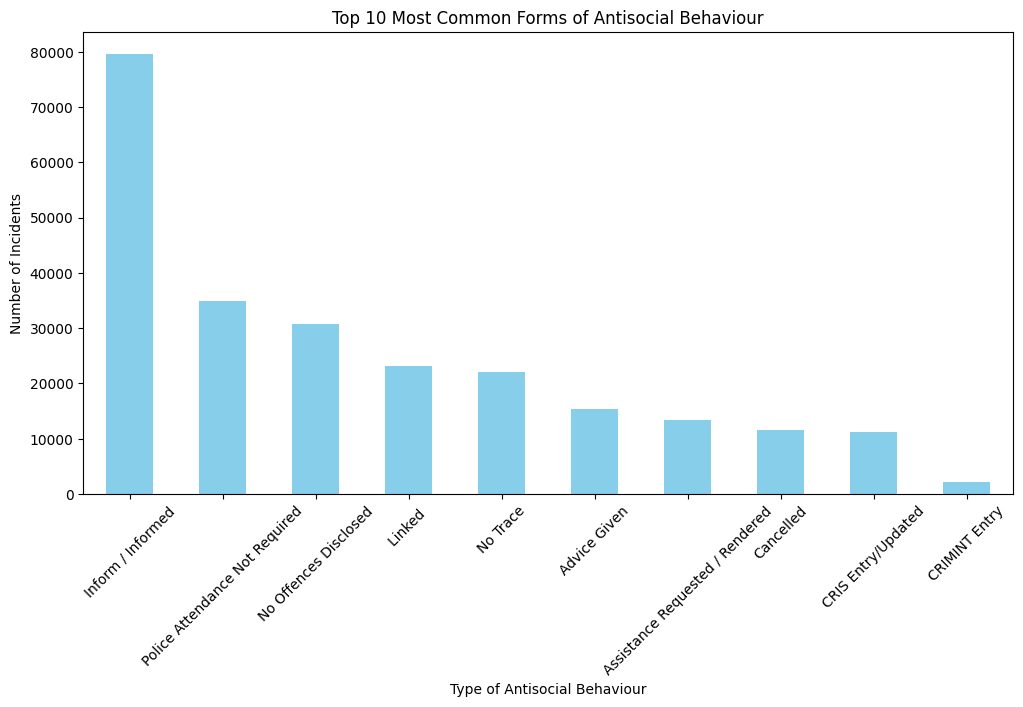

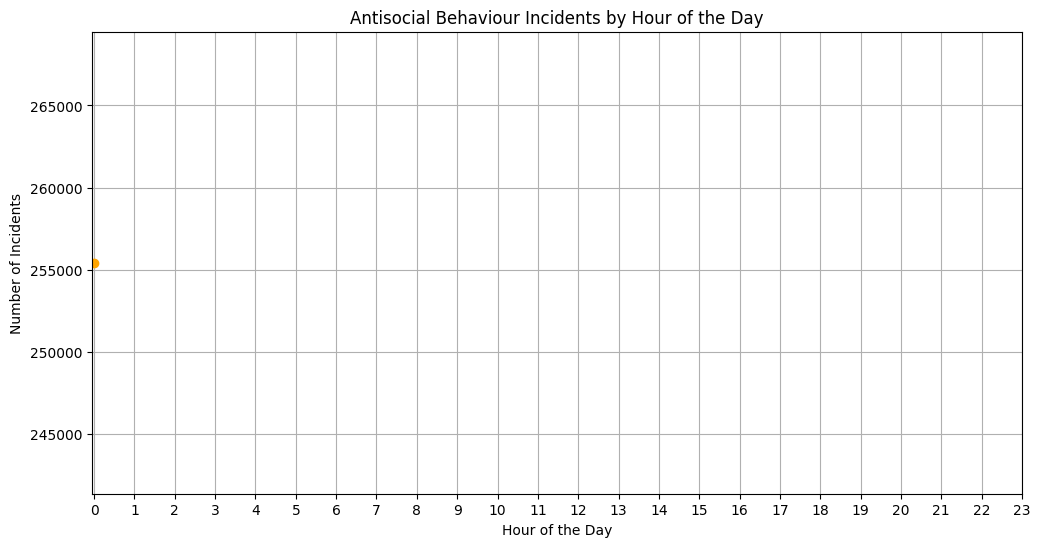

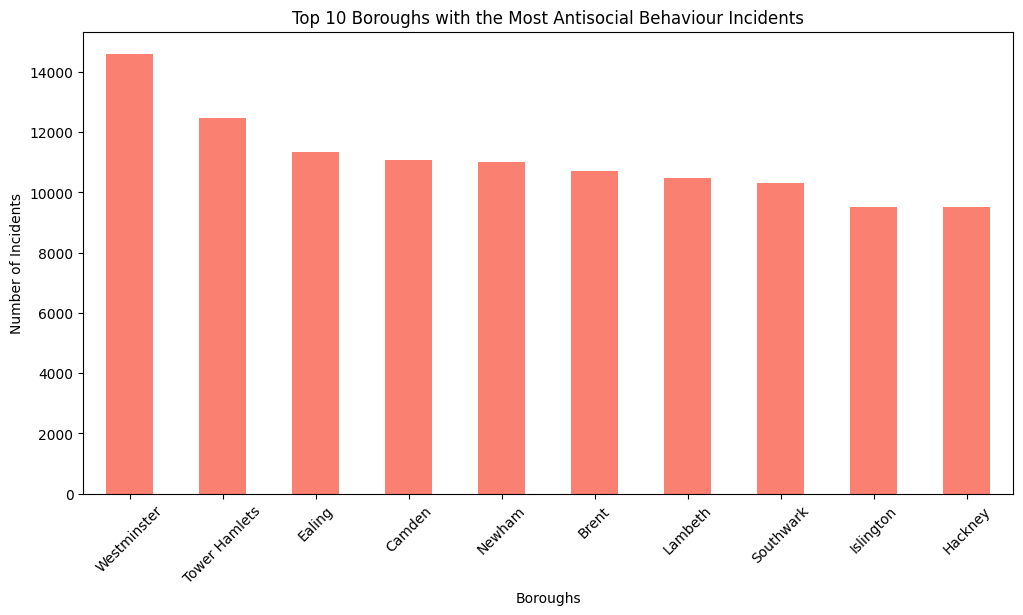

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/MPS_Antisocial_Behaviour--1-.csv', low_memory=False)

# Ensure datetime conversion
df['Datetime'] = pd.to_datetime(df['Datetime'])
df['Hour'] = df['Datetime'].dt.hour

### 1. Most Common Forms of Antisocial Conduct
# Assuming 'Resolution_Type_1' represents the type of antisocial conduct
most_common_asb = df['Resolution_Type_1'].value_counts().head(10)

plt.figure(figsize=(12, 6))
most_common_asb.plot(kind='bar', color='skyblue')
plt.title('Top 10 Most Common Forms of Antisocial Behaviour')
plt.xlabel('Type of Antisocial Behaviour')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.show()

### 2. Time When Antisocial Behaviour is Most Common
time_asb = df['Hour'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
time_asb.plot(kind='line', marker='o', color='orange')
plt.title('Antisocial Behaviour Incidents by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Incidents')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

### 3. Least Comfortable Boroughs due to Antisocial Behaviour
# Assuming 'Safer_Neighborhood_Team_Borough_Name' represents boroughs
borough_asb = df['Safer_Neighborhood_Team_Borough_Name'].value_counts().head(10)

plt.figure(figsize=(12, 6))
borough_asb.plot(kind='bar', color='salmon')
plt.title('Top 10 Boroughs with the Most Antisocial Behaviour Incidents')
plt.xlabel('Boroughs')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.show()

### Insights:
# - The first graph shows the most common antisocial conduct types.
# - The second graph highlights peak hours for antisocial activity.
# - The third graph identifies the boroughs most affected by antisocial behaviour.
